<a href="https://colab.research.google.com/github/KaihangShi/CE-400500-AI-for-Chemical-Engineers/blob/main/CE400500_Variational_Autoencoder_Drug_Discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Generating Drug-like Molecules Using Variational Autoencoder
Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo

**Learning objectives:**
- Understand how variational autoencoders (VAEs) map molecules into a continuous latent space.
- Build and train a simple multilayer perceptron (MLP) VAE to reconstruct and generate SMILES strings.
- Explore the latent space and generate novel drug-like molecules that are not in the original data set.

**References for the dataset:**
- Irwin, John J., and Brian K. Shoichet. "ZINC− a free database of commercially available compounds for virtual screening." *Journal of Chemical Information and Modeling* 45, no. 1 (2005): 177-182.
- Dataset subset hosted at the Aspuru-Guzik group repository: https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv

**References for variational autoencoder**:
- Gómez-Bombarelli, Rafael, Jennifer N. Wei, David Duvenaud, José Miguel Hernández-Lobato, Benjamín Sánchez-Lengeling, Dennis Sheberla, Jorge Aguilera-Iparraguirre, Timothy D. Hirzel, Ryan P. Adams, and Alán Aspuru-Guzik. "Automatic chemical design using a data-driven continuous representation of molecules." *ACS Central Science* 4, no. 2 (2018): 268-276.
- [Variational Autoencoder for Molecule Discovery](https://colab.research.google.com/github/DrKenReid/VAE-for-Molecule-Discovery/blob/main/Variational_Autoencoder_for_Molecule_Discovery.ipynb)
- [Drug Molecule Generation with VAE](https://colab.research.google.com/github/keras-team/keras-io/blob/master/examples/generative/ipynb/molecule_generation.ipynb)
- [Bead-Spring Polymer VAE](https://github.com/icomse/9th_workshop_ml_for_molecules/blob/main/Friday/Day5_VAE_example2.ipynb)

## 0. Preparation
- We will use PyTorch for the VAE implementation and RDKit to evaluate chemical properties. RDKit is an open-source cheminformatics library that provides robust tools for molecular representation, property computation, and structure manipulation directly from SMILES or other molecular formats.
- We need to install RDKit on Google Colab environment.

Let's select GPU device to accelerate our training in this notebook:

`Edit` -> `Notebook settings` -> select available GPU -> click `save`

In [ ]:
# Install once per environment
!pip install rdkit SmilesPE

In [ ]:
# Data handling and plotting helpers
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# PyTorch implements the neural network building blocks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

# Chemistry tools
from rdkit import Chem
from rdkit.Chem import QED
from rdkit.Chem import Draw
from rdkit import RDLogger
from SmilesPE.pretokenizer import atomwise_tokenizer
# Disable all RDKit logs
RDLogger.DisableLog('rdApp.*')

# Unsupervised learning tools
import umap

plt.style.use('seaborn-v0_8')

# Fix the random seeds so every student sees the same behavior
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## 1. Dataset
We use the [**ZINC – A Free Database of Commercially Available Compounds for
Virtual Screening**](https://bit.ly/3IVBI4x) dataset. The dataset comes with molecule
formula in SMILE representation along with their respective molecular properties such as
**logP** (water–octanal partition coefficient), **SAS** (synthetic
accessibility score) and **QED** (Qualitative Estimate of Drug-likeness). These molecular properties can be conveniently calculated using RDKit.

### 1.1 Load and Preview the ZINC Dataset
We download the public CSV file, keep a manageable subset for class demos, and inspect a few SMILES strings.

In [ ]:
# Public link to the ZINC subset used in many chemistry VAE tutorials
zinc_url = (
    'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/'
    'zinc_properties/250k_rndm_zinc_drugs_clean_3.csv'
)


print('Downloading ZINC subset...')
# pull the CSV directly from GitHub
df_full = pd.read_csv(zinc_url)

print(f'Total molecules available: {len(df_full):,}')

# Pick SMILES with no rings or only one ring to keep it simple
def has_no_rings(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False  # skip invalid SMILES
    return mol.GetRingInfo().NumRings() <= 1

# Filter the DataFrame
df = df_full[df_full["smiles"].apply(has_no_rings)].reset_index(drop=True)

print(f'Total molecules with no rings or only one ring: {len(df):,}')

Total molecules available: 249,455
Total molecules with no rings or only one ring: 21,653


In [ ]:
df.head()

,smiles,logP,qed,SAS
0,CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br\n,2.6374,0.824369,5.091438
1,COc1ccc(C(=O)N(C)[C@@H](C)C/C(N)=N/O)cc1O\n,0.9978,0.327297,2.852316
2,CCN(CC)C(=O)C[C@@H](C)[NH2+][C@H](C)c1cccc(F)c...,2.2362,0.825488,3.878254
3,O=C(CCCO)Nc1ccc(F)cc1F\n,1.6758,0.808810,1.728031
4,CCO[C@H]1C(=O)O[C@H]([C@@H](O)CO)C1=O\n,-1.7608,0.441574,4.085911


SMILES (Simplified Molecular Input Line Entry System) are the type of chemical notation that helps us to represent molecules and easy to be used by the computers. It is a simple string representation of molecules. Some examples include c1ccccc1 benzene, c1c(N(=O)=O)cccc1 Nitrobenzene. Also see an example below:

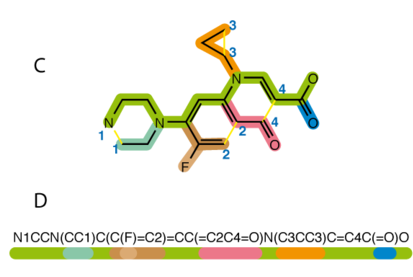

CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br



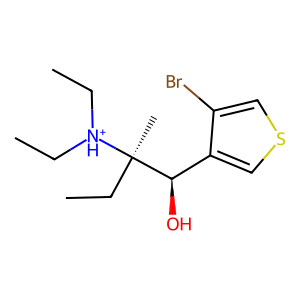

In [ ]:
# visualize the first smile string as an example molecule
print(df.loc[0, 'smiles'])
molecule = Chem.MolFromSmiles(df.loc[0, 'smiles'])
Draw.MolToImage(molecule)

### 1.2 Tokenization
Tokenization is the process of splitting text into basic units (tokens). Here we convert SMILES into sequences of characters. Simple character-level tokenization keeps the model easy to understand, even if it cannot capture every chemical rule.

Example:
SMILES: "CCO" → Tokenize: ["C", "C", "O"]


In [ ]:
# show example of tokenization
print(df['smiles'].iloc[0])

# use the SmilesPE atomwise tokenizer
tokens = atomwise_tokenizer(df['smiles'].iloc[0])
print(tokens)

CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br

['C', 'C', '[NH+]', '(', 'C', 'C', ')', '[C@]', '(', 'C', ')', '(', 'C', 'C', ')', '[C@H]', '(', 'O', ')', 'c', '1', 'c', 's', 'c', 'c', '1', 'Br']


We will add `<start>`/`<end>` markers to the tokenized sequence to indicate the start/end of SMILES so the decoder knows where to begin and stop.

All ML models, including VAE encoder/decoder, works on fixed-size feature vector. So we need to know the maximum SMILES length (plus two additional token `<start>` and `<end>`) in the dataset, and we will use this `max_length` as the size of all SMILES. For SMILES shorter than `max_length`, we will pad them with `<pad>` tokens.

In [ ]:
# add room for the <start> and <end> markers
max_length = df['smiles'].map(lambda x: len(atomwise_tokenizer(x))).max() + 2
print(f'Maximum SMILES length: {max_length}')

Maximum SMILES length: 60


### 1.3 Convert between SMILES and One-Hot Encoding

We transform SMILES strings into index sequences (one-hot encoding) and prepare PyTorch datasets for batching. Example of one-hot encoding of SMILES:

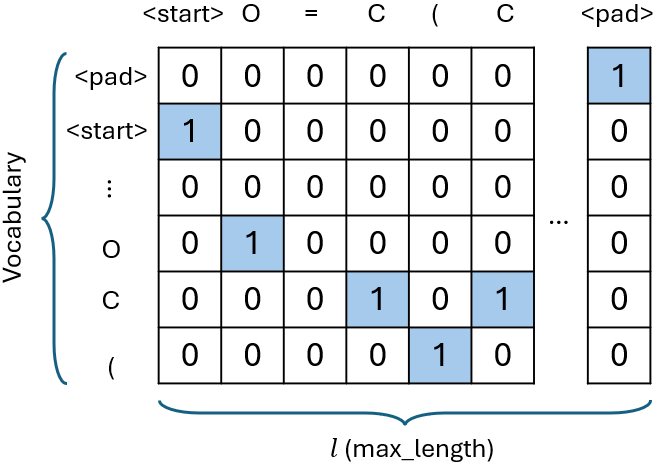

In [ ]:
# helper markers used during encoding
special_tokens = ['<pad>', '<start>', '<end>']

# Build a character-level vocabulary so we can turn SMILES text into numbers for the neural network
def build_vocabulary(smiles_series: pd.Series):

    # collect every unique character in all SMILES strings use atomwise_tokenizer
    charset = set()
    for smiles in smiles_series:
        tokens = atomwise_tokenizer(smiles)
        charset.update(tokens)
    # sort the characters to ensure consistent ordering
    charset = sorted(list(charset))

    # combine special tokens and characters into the final vocabulary
    vocab = special_tokens + charset
    # create mapping from tokens to indices so we can build one-hot vectors later using this token2indices map
    token_to_idx = {token: idx for idx, token in enumerate(vocab)}
    # create reverse mapping from indices to tokens for decoding later
    idx_to_token = {idx: token for token, idx in token_to_idx.items()}

    return vocab, token_to_idx, idx_to_token

# build the lookup tables from our subset of all SMILES strings
vocab, token_to_idx, idx_to_token = build_vocabulary(df['smiles'])

vocab_size = len(vocab)  # total number of distinct tokens

print(f'Vocabulary size: {vocab_size}')
print('All tokens:', vocab)

Vocabulary size: 44
All tokens: ['<pad>', '<start>', '<end>', '#', '(', ')', '/', '1', '=', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[N+]', '[N-]', '[NH+]', '[NH-]', '[NH2+]', '[NH3+]', '[O-]', '[P@@H]', '[P@@]', '[P@]', '[S-]', '[S@@]', '[S@]', '[n+]', '[n-]', '[nH+]', '[nH]', '\\', 'c', 'n', 'o', 's']


Let's first define two useful functions to convert SMILES to one-hot encoding vector and vice versa:

In [ ]:
# Define a function to convert SMILES to one-hot encoding
def smiles_to_one_hot(smiles):

    # prepend/append boundary markers
    tokens = ['<start>'] + atomwise_tokenizer(smiles) + ['<end>']
    if len(tokens) <= max_length:
        # pad with <pad> so all sequences share the same length
        tokens += ['<pad>'] * (max_length - len(tokens))
    else:
        # raise an error
        raise ValueError("max_length exceeded")

    # Create a one-hot matrix
    onehot = np.zeros((len(vocab), max_length), dtype=np.float32)
    for i, token in enumerate(tokens):
        idx = token_to_idx.get(token)
        onehot[idx, i] = 1.0

    # return flattened 1D vector (row by row)
    return onehot.flatten()

# Define a function to convert one-hot flattened vector back to SMILES
def one_hot_to_smiles(flat_onehot):

    # convert torch tensors to numpy
    if isinstance(flat_onehot, torch.Tensor):
        vec = flat_onehot.detach().cpu().numpy().ravel()
    else:
        vec = np.asarray(flat_onehot).ravel()

    # reshape flattened vector back to (vocab_size, max_length) matrix
    onehot_mat = vec.reshape(len(vocab), max_length)
    # get indices of max value (1) along each column/token
    indices = np.argmax(onehot_mat, axis=0).astype(int).tolist()

    # decode indices into tokens
    tokens = []
    for idx in indices:
        token = idx_to_token.get(int(idx))
        if token == '<end>':
            break
        if token in ('<pad>', '<start>'):
            continue
        tokens.append(token)

    return ''.join(tokens)


Original SMILES: COc1ccc(C(=O)N(C)[C@@H](C)C/C(N)=N/O)cc1O

Flattened one-hot vector length: 2640
One-hot encoding shape: (44, 60)
[[0. 0. 0. ... 1. 1. 1.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Converted SMILES: COc1ccc(C(=O)N(C)[C@@H](C)C/C(N)=N/O)cc1O


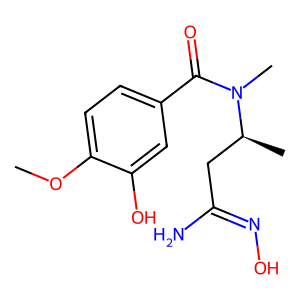

In [ ]:
# Let's try encoding and decoding a SMILES string
example_smiles = df['smiles'].iloc[1]
print('Original SMILES:', example_smiles)

# Convert the SMILES string to flattened one-hot
flat = smiles_to_one_hot(example_smiles)
print('Flattened one-hot vector length:', len(flat))
onehot = flat.reshape(len(vocab), max_length)
print('One-hot encoding shape:', onehot.shape)
print(onehot)

# Convert the flattened one-hot back to SMILES
converted_smiles = one_hot_to_smiles(flat)
print('Converted SMILES:', converted_smiles)

# draw decoded molecule
molecule = Chem.MolFromSmiles(converted_smiles)
Draw.MolToImage(molecule)

In [ ]:
# Encode all SMILES to flattened one-hot vectors
all_onehot = np.array([smiles_to_one_hot(smi) for smi in df['smiles']])

# data spliting into training adn testing
train_set, val_set = train_test_split(
    all_onehot,
    test_size=0.1,
    random_state=SEED,
    shuffle=True,
)
train_set

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

Similar to what we did in the previous [multilayer perceptron (MLP) tutorial](https://colab.research.google.com/drive/11v2PuH4fpzYBWNLacubk8xci6-6C5vVd?usp=sharing), let's build a DataLoader helper to streamline the data pipeline, making it efficient to manage, prepare, and feed data to your PyTorch models during training and evaluation. (Especially useful when having a large dataset).

Key benefits of having a DataLoader are:

- Training stability: Shuffling prevents the model from learning patterns based on data order
- Memory management: Processing in batches allows you to work with datasets larger than your available RAM
- GPU utilization: Batched operations are much more efficient on GPUs than individual samples

By default, PyTorch assigns data points into batches without replacement.

In [ ]:
# Helper function to create a DataLoader
def make_loader(features, batch_size=128, shuffle=True):
    """
    Creates a PyTorch DataLoader from features and labels.

    Args:
        features (np.ndarray): NumPy array of features.
        batch_size (int): The batch size for the DataLoader.
        shuffle (bool): Whether to shuffle the data.

    Returns:
        torch.utils.data.DataLoader: The created DataLoader.
    """
    # Convert NumPy arrays to PyTorch tensors
    X = torch.tensor(features, dtype=torch.float32).to(device)

    return DataLoader(X, batch_size=batch_size, shuffle=shuffle)

# will use these loaders for training and validation
train_loader = make_loader(train_set, batch_size=128, shuffle=True)
val_loader = make_loader(val_set, batch_size=128, shuffle=False)

## 2. Variational Autoencoder (VAE)
We build a lightweight MLP-based VAE similar to the neural network style used earlier in the course. The encoder compresses one-hot SMILES representations to a latent space; the decoder reconstructs one-hot SMILES representation from numerical latent vectors.

### 2.1 Define the Encoder and Decoder for VAE
Keeping each component modular makes experimentation easier. The encoder outputs the mean and log-variance of a Gaussian distribution so we can sample latent vectors via the reparameterization trick.

Let's define the encoder first:

In [ ]:
# Define an Encoder class
# The new Encoder class inherits all the data and behaviors (methods) from the parent class "nn.Module".
class Encoder(nn.Module):

    # initialize the Encoder
    # use two latent dimention to keep latent space easy to visualize
    def __init__(self, input_dim, hidden_dim=[512], latent_dim=64):

        # Call the constructor of the parent class (nn.Module)
        super().__init__()

        # build MLP backbone from the hidden_dim list
        layers = []
        in_dim = input_dim

        for h in hidden_dim:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        self.backbone = nn.Sequential(*layers)

        # last hidden unit size is the input to the latent parameter heads
        # predicts the mean of q(z|x)
        self.mu_layer = nn.Linear(hidden_dim[-1], latent_dim)
        # predicts log variance of q(z|x) (more numerically stable than variance)
        self.logvar_layer = nn.Linear(hidden_dim[-1], latent_dim)

    # It is a requirement to define the "forward" pass (name should match) for any nn.Modules subclass (custom neural network).
    # This forward method defines how the input data is processed through the network.
    def forward(self, x):

        # pass input through the MLP backbone
        hidden = self.backbone(x)
        # mean of the latent Gaussian
        mu = self.mu_layer(hidden)
        # log variance
        logvar = self.logvar_layer(hidden)

        # mu and logvar have shape (batch_size, latent_dim)
        return mu, logvar

Now let's define the decoder:

In [ ]:
# Define a Decoder class
class Decoder(nn.Module):

    def __init__(self, output_dim, latent_dim=64, hidden_dim=[128,256,512]):

        super().__init__()

        # build MLP backbone from the hidden_dim list (mirror of the Encoder)
        layers = []
        in_dim = latent_dim

        for h in hidden_dim:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        self.backbone = nn.Sequential(*layers)

        # output layer to project back to sequence space
        self.output_layer = nn.Linear(hidden_dim[-1], output_dim)

    # Forward method to project latent vector back to sequence space
    def forward(self, z):
        hidden = self.backbone(z)
        x_hat = self.output_layer(hidden)
        return x_hat


Let's wrap encoder and decoder to a VAE class:

In [ ]:
# Define the full VAE model by combining Encoder and Decoder
class MoleculeVAE(nn.Module):

    def __init__(self, encoder, decoder):

        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):

        # encode into latent distribution parameters
        mu, logvar = self.encoder(x)
        # convert log variance into standard deviation
        std = torch.exp(0.5 * logvar)
        # random noise used for the reparameterization trick
        eps = torch.randn_like(std)
        # z is now fully differentiable
        z = mu + eps * std
        # decode into reconstructed logits
        x_hat = self.decoder(z)
        return x_hat, mu, std

Now let's instantiate a VAE model using the Python class we just built:

In [ ]:
# input dimension is fixed and equal to the max_length we determined before
flat_onehot_dim = len(vocab) * max_length

# instantiate encoder, decoder, and VAE model
# use default hidden dimension and latent dimensions for encoder and decoder
encoder = Encoder(input_dim=flat_onehot_dim)
decoder = Decoder(output_dim=flat_onehot_dim)
# bundle into a VAE and move to GPU/CPU
vae = MoleculeVAE(encoder, decoder).to(device)

print(vae)

MoleculeVAE(
  (encoder): Encoder(
    (backbone): Sequential(
      (0): Linear(in_features=2640, out_features=512, bias=True)
      (1): ReLU()
    )
    (mu_layer): Linear(in_features=512, out_features=64, bias=True)
    (logvar_layer): Linear(in_features=512, out_features=64, bias=True)
  )
  (decoder): Decoder(
    (backbone): Sequential(
      (0): Linear(in_features=64, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=512, bias=True)
      (5): ReLU()
    )
    (output_layer): Linear(in_features=512, out_features=2640, bias=True)
  )
)


### 2.2 Define Loss Function for VAE
We define the loss of VAE as a combination of **reconstruction accuracy** and **latent space regularization**:

- **Reconstruction loss:** we use cross-entropy to measure how well the decoder can reconstruct the original tokens:$$
  \mathcal{L}_{\text{recon}}
  \;=\;
  - \sum_{t=1}^{max\_length}
  \log
  \frac{\exp(\mathrm{logits}_{t, y_t})}
       {\sum_{k} \exp(\mathrm{logits}_{t, k})}
  $$ where $\mathrm{logits}_{t, y_t}$ is the unnormalized decoder output for the **true class** at position $t$.

- **KL divergence:** KL divergence encourages the learned latent vectors to stay close to a unit Gaussian $\mathcal{N}(0, I)$, promoting a smooth and continuous latent space. With encoder outputs $\mu$ and $\sigma$ in $d$ latent dimensions,

  $$
  \mathrm{KL}
  \;=\;
  \sum_{i=1}^{d}
  \Big(
    -\log \sigma_i
    + \tfrac{1}{2}\big(\sigma_i^2 + \mu_i^2\big)
    - \tfrac{1}{2}
  \Big)
  $$

- **Total loss:** combines the two components with a weighting factor $\beta$ and is averaged over batch:  
  $$
  \mathcal{L}
  \;=\;
  \operatorname{mean}_{\text{batch}}
  \Big(
    \mathcal{L}_{\text{recon}} \;+\; \beta \cdot \mathrm{KL}
  \Big)
  $$
  A higher $\beta$ enforces stronger regularization on the latent space, while a lower $\beta$ prioritizes better reconstruction.



In [ ]:
# Define the VAE loss function
def vae_loss_function(vaemodel, x, beta):

    x = x.to(device)

    # forward pass through VAE
    x_hat, mu, std = vaemodel(x)

    # ---- Reconstruction loss ----
    # get the indices of the true tokens from one-hot encoding
    true_indices = x.view(-1, len(vocab), max_length).argmax(dim=1)  # shape: (batch_size, max_length)
    # reshape reconstructed x_hat to (batch_size, vocab_size, max_length)
    x_hat_matrix = x_hat.view(-1, len(vocab), max_length)

    # compute cross-entropy loss per token
    # cross_entropy function expects unnormalized logits for input as it will internally apply softmax to normalize
    # output shape: (batch_size, max_length)
    recon_per_token = F.cross_entropy(
        input=x_hat_matrix,  # logits from the decoder
        target=true_indices,  # true token indices
        ignore_index=token_to_idx['<pad>'],  # ignore padding tokens in loss
        reduction='none'  # we want per-sample loss
    )

    # sum over all tokens in the sequence
    recon = recon_per_token.sum(dim=1)

    # ---- KL Divergence loss ----
    # KL divergence per latent dimension
    # mu and std have shape (batch_size, latent_dim)
    kl_per_dim = -torch.log(std) + 0.5 * (std.pow(2) + mu.pow(2)) - 0.5
    kl = kl_per_dim.sum(dim=1)

    # average over batch
    loss = (recon + beta * kl).mean()

    return loss, recon.mean(), kl.mean()


### 2.3 Train the VAE
We optimize the model using Adam. Tracking both reconstruction and KL terms helps us diagnose the learning dynamics during class.

In [ ]:
# define a training function
def train_vae(
    model,                                  # MoleculeVAE model
    train_loader,                           # DataLoader for training data
    val_loader,                             # DataLoader for validation data
    num_epochs,                             # maximum epochs to run
    lr,                                     # learning rate for Adam
    beta,                                   # KL weight passed to vae_loss_function
    patience=10,                            # early stopping patience (None disables early stopping)
):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # initializae history dictionary to store losses
    history = {'loss': [],
               'recon': [],
               'kl': [],
               'val_loss': [],
               'val_recon': [],
               'val_kl': []}

    best_val = float('inf')
    best_state = None
    patience_counter = 0

    # Start training loop
    for epoch in range(1, num_epochs + 1):

        # ----- Training phase -----
        model.train()
        running_loss = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for batch in train_loader:
            x = batch.to(device)
            optimizer.zero_grad()
            loss, recon, kl = vae_loss_function(model, x, beta=beta)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_recon += recon.item() * x.size(0)
            running_kl += kl.item() * x.size(0)

        # calculate average losses over the entire training set per epoch
        train_loss = running_loss / len(train_loader.dataset)
        train_recon = running_recon / len(train_loader.dataset)
        train_kl = running_kl / len(train_loader.dataset)

        # ----- Validation phase -----
        # set model to evaluation mode
        model.eval()
        val_running = 0.0

        # turn off gradient calculations for validation to save memory and computations
        with torch.no_grad():
            for batch in val_loader:

                x_val = batch.to(device)
                val_loss_batch, _, _ = vae_loss_function(model, x_val, beta=beta)
                val_running += val_loss_batch.item() * x_val.size(0)

        # compute average validation loss over the entire validation set
        val_loss = val_running / len(val_loader.dataset)

        # record history
        history['loss'].append(train_loss)
        history['recon'].append(train_recon)
        history['kl'].append(train_kl)
        history['val_loss'].append(val_loss)

        # print progress
        print(f"Epoch {epoch:02d}/{num_epochs} | Loss: {train_loss:.4f} | Recon: {train_recon:.4f} | KL: {train_kl:.4f} | Val Loss: {val_loss:.4f}")

        # early stopping
        if val_loss < best_val:
            best_val = val_loss
            # store CPU-cloned tensors for safety
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            if patience is not None:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch} (best val {best_val:.6f})")
                    break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


Again, here we want to learn the inner working of VAE and its training protocols. If you are familiar with VAE and its implementation, there are more convenient high-level Python packages available, such as `pythae`, with minimal coding requirement for implementation of VAE.  

Now let's training the VAE model using default hyperparameters.

In [ ]:
# focus on reconstruction loss with beta=0.1 enough to constraint distribution around N(0,1)
history = train_vae(vae, train_loader, val_loader, num_epochs=200, lr=1e-3, beta=0.1, patience=10)

Epoch 01/200 | Loss: 69.0735 | Recon: 68.9590 | KL: 1.1444 | Val Loss: 66.7506
Epoch 02/200 | Loss: 64.4591 | Recon: 64.0990 | KL: 3.6011 | Val Loss: 63.5699
Epoch 03/200 | Loss: 59.1268 | Recon: 58.0441 | KL: 10.8264 | Val Loss: 54.8631
Epoch 04/200 | Loss: 50.3728 | Recon: 48.1316 | KL: 22.4114 | Val Loss: 47.2899
Epoch 05/200 | Loss: 43.6936 | Recon: 40.8181 | KL: 28.7546 | Val Loss: 42.2695
Epoch 06/200 | Loss: 38.5709 | Recon: 35.1989 | KL: 33.7193 | Val Loss: 37.9725
Epoch 07/200 | Loss: 34.6087 | Recon: 30.9221 | KL: 36.8660 | Val Loss: 35.1300
Epoch 08/200 | Loss: 31.4381 | Recon: 27.5647 | KL: 38.7337 | Val Loss: 33.0217
Epoch 09/200 | Loss: 29.0338 | Recon: 25.0308 | KL: 40.0293 | Val Loss: 31.4456
Epoch 10/200 | Loss: 26.9625 | Recon: 22.8744 | KL: 40.8812 | Val Loss: 30.2413
Epoch 11/200 | Loss: 25.3034 | Recon: 21.1541 | KL: 41.4932 | Val Loss: 29.3768
Epoch 12/200 | Loss: 23.8993 | Recon: 19.7167 | KL: 41.8265 | Val Loss: 28.7116
Epoch 13/200 | Loss: 22.6462 | Recon: 18.4

Here, we will skip the hyperparameter tunning (e.g., tunning `hidden_dim`, `latent_dim`, `beta`, `lr`). If necessary, you can adopt the same tunning procedure with the `Optuna` packageas as we have introduced in the [MLP hands-on session](https://colab.research.google.com/drive/11v2PuH4fpzYBWNLacubk8xci6-6C5vVd?usp=sharing).

Let's plot the learning curve:

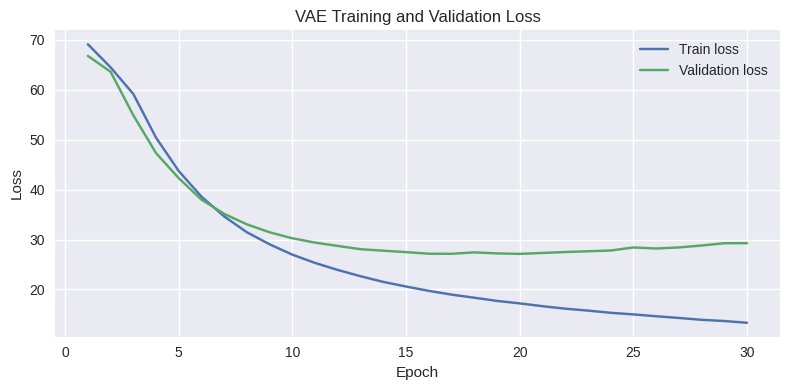

In [ ]:
# Plot the training and validation loss curves to monitor learning progress
epochs = range(1, len(history['loss']) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history['loss'], label='Train loss')  # reconstruction + KL on training batches
plt.plot(epochs, history['val_loss'], label='Validation loss')  # same metrics on the validation split
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

Let's save the trained VAE model to Torch Script format. We will use this trained model in the next LLM tutorial to build an agentic AI for autonomous molecule generation.

In [ ]:
# Save the trained VAE model to Torch Script format
scripted_vae = torch.jit.script(vae.cpu())
torch.jit.save(scripted_vae, 'molecule_vae.pt')

## 3. Generate New Drug-Like Molecules

### 3.1 Visualization of Learned Latent Space


In [ ]:
# feed all molecules (training + validation) through the encoder to get their latent representations
vae.eval()
# Move the model to the GPU
vae.to(device)
all_latent = []
with torch.no_grad():
    for batch in make_loader(all_onehot, batch_size=128, shuffle=False):
        mu, logvar = vae.encoder(batch.to(device))
        all_latent.append(mu.cpu().numpy())

# concatenate all batches into a single array
all_latent = np.vstack(all_latent)

We can see distribution of mean (mu) is centered around 0 which is forced by the soft loss of KL divergence during the training.

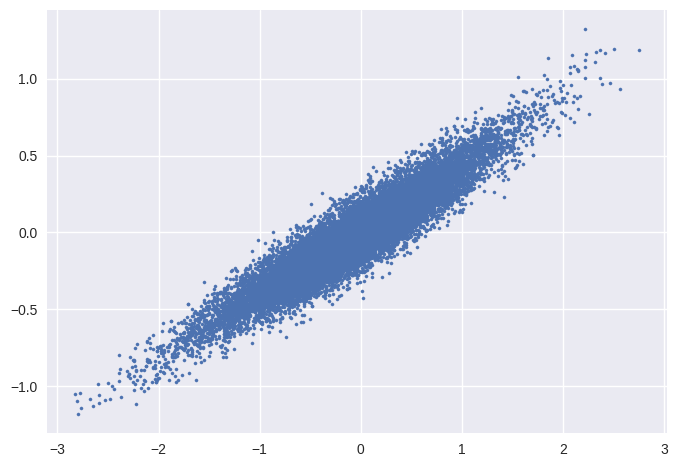

In [ ]:
# plot the first two dimensions in the latent space
plt.scatter(all_latent[:,0],all_latent[:,1],s=5)
plt.show()

Let's plot the high-dimensional latent space using dimensionality reduction method (UMAP is applied here) to interpret how VAE encode the molecules. We color each point by QED to see where drug-like molecules cluster.

In [ ]:
# calculate QED scores
qed_scores = []
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    qed_value = QED.qed(mol)
    qed_scores.append(qed_value)

# pick top 50 with the highest QED score in the dataset
top_n = 50
top_indices = df['qed'].nlargest(top_n).index
top_molecules = all_onehot[top_indices]

In [ ]:
# use UMAP to visualize higher-dimensional latent spaces
reducer = umap.UMAP(n_components=2, random_state=SEED, transform_seed= SEED)
latent_2d = reducer.fit_transform(all_latent)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


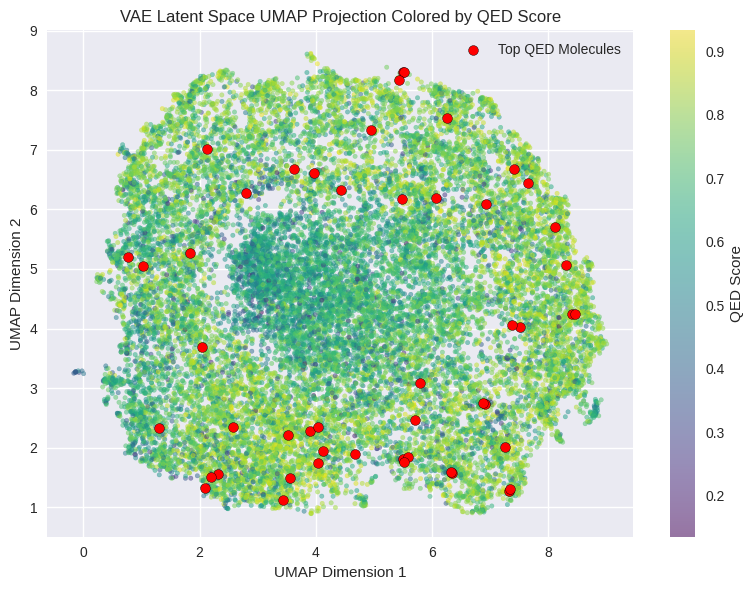

In [ ]:
# plot UMAP projection colored by QED scores together
# and highlight the top molecules
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1],c=qed_scores, alpha=0.5, s=10, cmap='viridis')
plt.colorbar(scatter, label='QED Score')
# highlight top molecules
plt.scatter(latent_2d[top_indices, 0], latent_2d[top_indices, 1],
            c='red', edgecolors='black', s=50, label='Top QED Molecules')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('VAE Latent Space UMAP Projection Colored by QED Score')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2 Generate New Molecules with Higher QED (Drug-Likeness)


Let's start with those top-50 molecules and sample around them to generate new molecules with simiarly high QED values.

In [ ]:
# encode to get top molecules latent representation
vae.eval()
with torch.no_grad():
    mu, _ = vae.encoder(torch.tensor(top_molecules, dtype=torch.float32).to(device))

# sample points around top molecules in latent space
num_samples_per_molecule = 10
sampling_std = 0.1  # standard deviation for Gaussian noise
sampled_z = []
for i in range(top_n):
    for _ in range(num_samples_per_molecule):
        noise = torch.randn(vae.encoder.mu_layer.out_features).to(device) * sampling_std
        sampled_point = mu[i] + noise
        sampled_z.append(sampled_point)

# decode the sampled latent vectors back to SMILES
decoded_smiles = []
vae.eval()
with torch.no_grad():
    for z in sampled_z:
        x_hat = vae.decoder(z.unsqueeze(0))
        smi = one_hot_to_smiles(x_hat.squeeze(0))
        decoded_smiles.append(smi)

# only keep valid and unique SMILES
valid_smiles = set()
for smi in decoded_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_smiles.add(smi)

print(valid_smiles)
len(valid_smiles)

{'CC[C@@](C)(NC(=O)c1cc(C)c(Br)s1)C(=O)[O-]', 'CN(CC(=O)C[C@@H](C#N)C(C)(C)C)S(=O)c1ccccc1', 'Cc1ccc(F)c(C(NC(=O)NC(C)(C)C)S(C)(=O)=O)c1', 'C[NH+](CCCCC)C(=O)Nc1ccc(Br)c(F)c1', 'C[C@H](CCCCC)C(=O)Nc1ccc(F)c(F)c1', 'CC[C@H](Cc1ccc(Cl)c(F)c1)S(C)(=C)=O', 'CC(C(=O)NC(C)(C)C)[S@@](=O)Cc1ccccc1Cl', 'CC[C@H](Cc1ccc(Cl)c(F)c1)S(N)(=C)=O', 'CC[C@@](C)(NC(=O)c1c(Cl)cccc1Cl)C(=O)[O-]', 'COc1cc(S(=O)(=O)NC(C)C)ccc1Br', 'CC[C@](C)(C#C)NC(=O)c1cc(F)ccc1Br', 'C[C@H](Nc1ccc(F)cc1Br)[C@@H](C)C(=O)[O-]', 'CC(C(=O)NC(C)(C)C)C(=O)Cc1ccccc1Cl', '[NH3+][C@H](Nc1ccc(F)cc1Br)[C@@H](C)C(=O)[O-]', 'CNC(=O)COc1cc(C)c(Br)c(N)c1C', 'CC[C@@H](NC(=O)N(C)C)c1ncc(C)cc1Br', 'COc1cc(S(=O)(=O)NC(C)C)ccc1Cl', 'CC(=O)N[C@@H](C)C(=O)N(C)[C@H](C)c1ccc(Cl)cc1', 'C[C@H](CCCCC)C(=O)Nc1ccc(Br)c(F)c1', 'C[C@H](C(=O)NC(C)(C)C)[S@@](=O)Nc1ccccc1Cl', 'CC[C@@H](CC(=O)N(C)C)c1ncc(C)cc1Br', 'CNC(=O)[C@@H](C)CN(C)C(=O)c1cccc(Br)c1Cl', 'CC[C@@](C)(NC(=O)c1cc(Cl)c(Br)s1)C(=O)S', 'CC[C@](C)(CCC)NC(=O)c1cc(F)ccc1Br', 'C[C@H](C(=O)NC(C)(C)C

64

In [ ]:
# check if these generate molecules are novel (not in the available set)
train_smiles_set = set(df['smiles'].values)
novel_smiles = [smi for smi in valid_smiles if smi not in train_smiles_set]
len(novel_smiles)

64

Let's visualize the distribution of QED values of these novel, newly generated molecules, compared to the original QED distribution in the ZINC dataset.

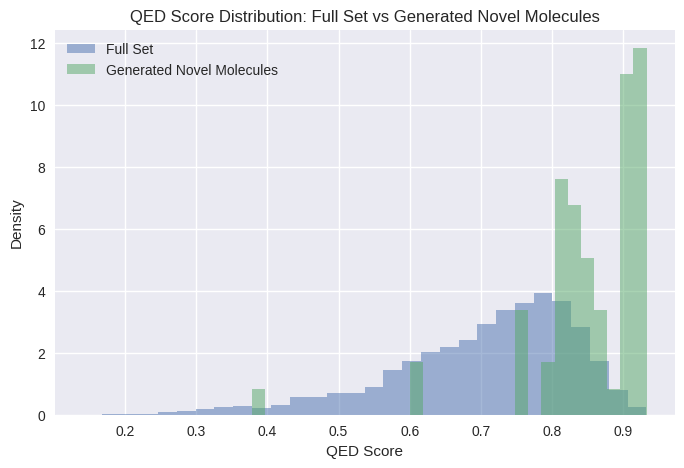

In [ ]:
# calculate QED scores for the novel molecules
qed_scores_novel = []
for smi in novel_smiles:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        qed = Chem.QED.qed(mol)
        qed_scores_novel.append(qed)

# plot histogram of QED scores for the novel molecules against in the training set
plt.figure(figsize=(8, 5))
plt.hist(df['qed'], bins=30, alpha=0.5, label='Full Set', density=True)
plt.hist(qed_scores_novel, bins=30, alpha=0.5, label='Generated Novel Molecules', density=True)
plt.xlabel('QED Score')
plt.ylabel('Density')
plt.title('QED Score Distribution: Full Set vs Generated Novel Molecules')
plt.legend()
plt.show()

**Going Further:**
- Potentially we can buil a predictive ML model (e.g., MLP) to correlate latent mu vector (treated as a feature vector of 64 dimension) with the QED values, and then interrogate this predictive model to find optimal latent mu vector for higher QED value.
- Alternative to a predictive ML model, we could also use prescriptive AI (e.g., genetic algorithm or Bayesian optimization) to find latent mu vector that corresponds to the global maximum of QED.
- Currently we used simple MLPs as encoder and decoder and they cannot correct understand the sequential relation in SMILES. Further improvement could be made to replace MLPs with recurrent neural network, transformer, or LSTM (long-short term memory) model.
- Further tuning hyperparameters of VAE model could also improve model's performance (e.g.,sucess rate of reconstructing molecules)